Iteration 1: Cost 5031.3015, Weight 0.21744528996901658, Bias 1.3877
Iteration 101: Cost 185.56941123866557, Weight 9.459227106883091, Bias 60.3672282719577
Iteration 201: Cost 100.34293399589959, Weight 10.684868107118445, Bias 68.18906711826675
Iteration 301: Cost 98.84397526476002, Weight 10.847412072256065, Bias 69.22639591234459
Iteration 401: Cost 98.81761165863254, Weight 10.868968580725983, Bias 69.36396599633204


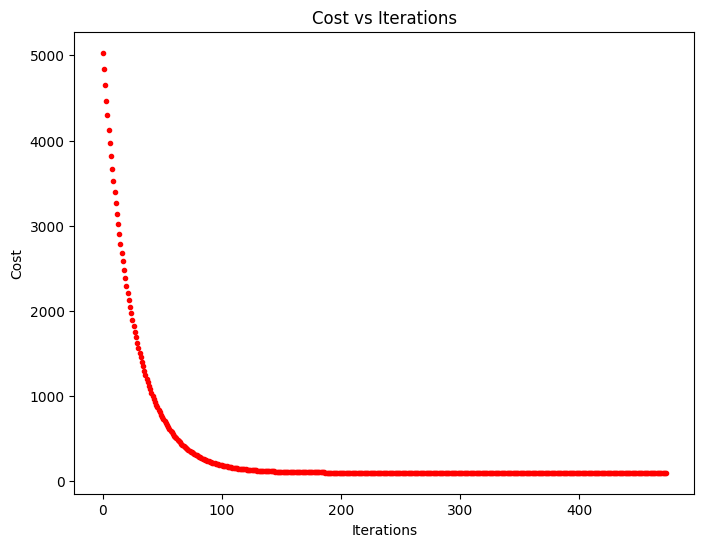

Estimated Weight: 10.87151030998278, Estimated Bias: 69.38018689350649


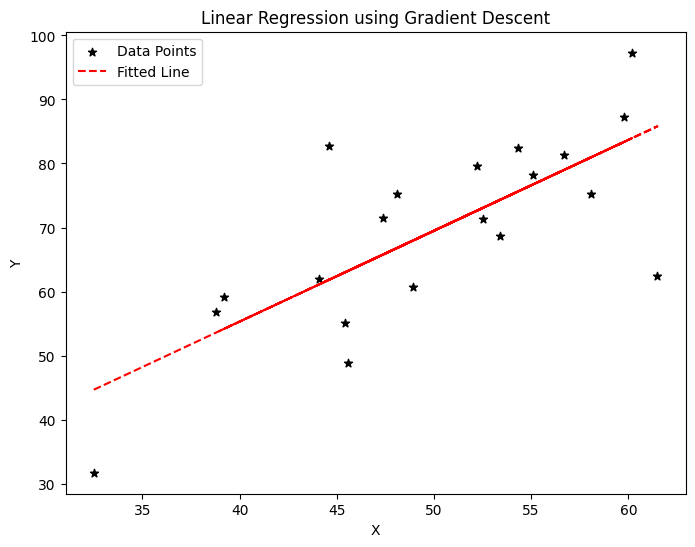

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

def mean_squared_error(y_true, y_predicted):
    cost = np.sum((y_true - y_predicted)**2) / len(y_true)
    return cost

def gradient_descent(x, y, iterations=1000, learning_rate=0.01,
                     stopping_threshold=1e-6):
    current_weight = 0.0
    current_bias = 0.0

    n = float(len(x))
    costs = []
    previous_cost = None
    for i in range(iterations):
        y_predicted = current_weight * x + current_bias
        current_cost = mean_squared_error(y, y_predicted)
        if previous_cost and abs(previous_cost - current_cost) <= stopping_threshold:
            break
        previous_cost = current_cost
        costs.append(current_cost)

        weight_derivative = -(2/n) * sum(x * (y - y_predicted))
        bias_derivative = -(2/n) * sum(y - y_predicted)
        current_weight = current_weight - learning_rate * weight_derivative
        current_bias = current_bias - learning_rate * bias_derivative

        if i % 100 == 0:
            print(f"Iteration {i+1}: Cost {current_cost}, Weight {current_weight}, Bias {current_bias}")

    plt.figure(figsize=(8,6))
    plt.plot(range(len(costs)), costs, 'r.')
    plt.title("Cost vs Iterations")
    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.show()

    return current_weight, current_bias

def main():

    X = np.array([32.5, 53.4, 61.5, 47.4, 59.8, 55.1, 52.2, 39.2, 48.1, 52.5, 45.4,
                  54.3, 44.1, 58.1, 56.7, 48.9, 44.6, 60.2, 45.6, 38.8])
    Y = np.array([31.7, 68.7, 62.5, 71.5, 87.2, 78.2, 79.6, 59.1, 75.3, 71.3, 55.1,
                  82.4, 62.0, 75.3, 81.4, 60.7, 82.8, 97.3, 48.8, 56.8])

    scaler = StandardScaler()
    X_normalized = scaler.fit_transform(X.reshape(-1, 1)).flatten()

    estimated_weight, estimated_bias = gradient_descent(X_normalized, Y,
                                                        iterations=2000, learning_rate=0.01)

    print(f"Estimated Weight: {estimated_weight}, Estimated Bias: {estimated_bias}")

    Y_pred = estimated_weight * X_normalized + estimated_bias

    plt.figure(figsize=(8,6))
    plt.scatter(X, Y, color='black', label='Data Points',marker='*')
    plt.plot(X, Y_pred, color='red', linestyle='--', label='Fitted Line')
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Linear Regression using Gradient Descent")
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()